Tile and Trouble
--

<img src='https://www.janestreet.com/puzzles/TileAndTrouble_updated.png' width=500 align='center'/>

Add square tiles to the 12-by-12 grid so that the total points in each row and each column matches the corresponding value outside the grid.

- A tile can have any side length (e.g., 1-by-1, 2-by-2, 3-by-3, etc.)
- Every cell within an n-by-n tile is worth n points.
- Tiles may not overlap. Not every cell in the 12-by-12 grid needs to be inside one of the tiles.
- For your answer, submit the product of the areas of each contiguous empty space in the solved grid.

In [41]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ortools.sat.python import cp_model

Visualisation
--

Let's use a heatmap to visualise a little grid showing what numbers go where for the solution.

In [36]:
def grid_plotter(array: np.array, x_list: np.array, y_list: np.array) -> None:
    mask = array == 0
    ax = sns.heatmap(
        array, cmap="tab20", annot=True, annot_kws={"fontsize":20, "color": "black"}, cbar=False, linewidths=2, linecolor="black",
        xticklabels=x_list, yticklabels=y_list, mask=mask
    )
    ax.tick_params(axis="both", length=0, rotation=0, labelsize=16)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    plt.figure(figsize = (8,8))
    plt.show()

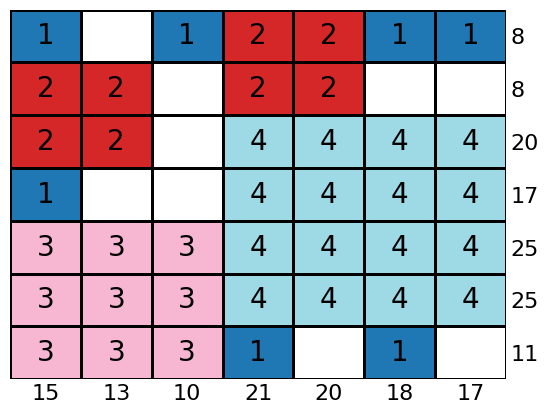

<Figure size 800x800 with 0 Axes>

In [12]:
#Test visualisation
grid = np.array([1, 0, 1, 2, 2, 1, 1, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 4, 4, 4, 4, 1, 0, 0, 4, 4, 4, 4, 3, 3, 3, 4, 4, 4, 4, 3, 3, 3, 4, 4, 4, 4, 3, 3, 3, 1, 0, 1, 0]).reshape((7,7))
x_list = [15, 13, 10, 21, 20, 18, 17]
y_list = [8, 8, 20, 17, 25, 25, 11]
grid_plotter(grid, x_list, y_list)

In [46]:
x_list = [30, 35, 45, 43, 41, 28, 25, 29, 25, 38, 18, 20]
y_list = [12, 17, 43, 44, 34, 42, 43, 21, 36, 29, 30, 26]

start = time.perf_counter()
model = cp_model.CpModel()
n = 12
X = np.array([[model.NewIntVar(0, 12, f"x{[j, i]}") for i in range(n)] for j in range(n)])

#Testing, can delete next 3 rows if forgot what they were doing
corners = list(range(0, 12, 3))
squares = np.vstack([X[i : i + 3, j : j + 3].reshape(-1) for i in corners for j in corners])
stacked = np.vstack([X, X.T, squares])

print(squares)

#sum row constraints

for idx, row in enumerate(X):
    e = cp_model.LinearExpr.Sum(row)
    model.add(e == y_list[idx])

for idx, row in enumerate(X.T):
    e = cp_model.LinearExpr.Sum(row)
    model.add(e == x_list[idx])
    
s = cp_model.CpSolver()

status = s.solve(model)

if status:
    sol = np.array([[s.value(X[j, i]) for i in range(n)] for j in range(n)])
    print(sol)
    print("Found solution")

end = time.perf_counter()
print(f"Time elapsed is {(end - start):.2f} seconds")

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 9 and the array at index 3 has size 0

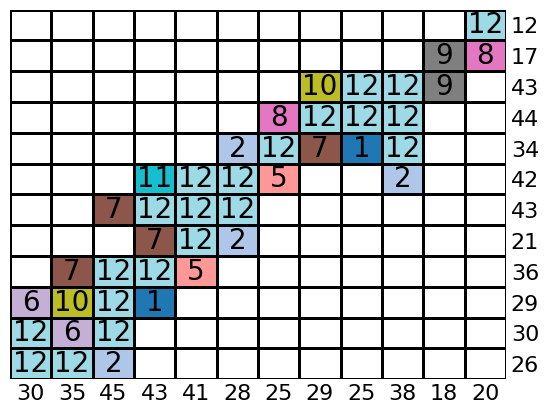

<Figure size 800x800 with 0 Axes>

In [40]:
grid_plotter(sol, x_list, y_list)